# Points per Set Analysis

How many points are played in a completed ATP set? Uses `set_stats` from `atp/data/atp.db` (one row per player per set; both players' `total_pts` always agree, so either row gives the set's point count).

Partial sets (e.g., abandoned mid-set in a RET match) are excluded; completed sets from RET matches are kept.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

DB_PATH = "../atp/data/atp.db"

query = """
SELECT s.year, s.event_id, s.match_code, s.set_number,
       MAX(s.total_pts)              AS total_pts,
       MAX(CAST(s.set_score AS INT)) AS winner_games,
       MIN(CAST(s.set_score AS INT)) AS loser_games,
       m.surface, m.reason
FROM set_stats s
JOIN matches m ON m.year = s.year AND m.event_id = s.event_id AND m.match_code = s.match_code
GROUP BY s.year, s.event_id, s.match_code, s.set_number
"""

with sqlite3.connect(DB_PATH) as con:
    sets = pd.read_sql(query, con)

completed = ((sets["winner_games"] == 6) & (sets["loser_games"] <= 4)) | (
    (sets["winner_games"] == 7) & (sets["loser_games"].isin([5, 6]))
)
print(f"Total sets: {len(sets)}, dropped as partial: {(~completed).sum()}")
print(sets.loc[~completed, ["winner_games", "loser_games", "reason"]].value_counts())

sets = sets[completed].copy()
sets["score_label"] = sets["winner_games"].astype(str) + "-" + sets["loser_games"].astype(str)
sets["is_tiebreak"] = sets["score_label"] == "7-6"
sets.head()

Total sets: 3266, dropped as partial: 30
winner_games  loser_games  reason
0             0            RET       6
3             1            RET       4
              3            RET       2
5             3            RET       2
1             0            RET       2
4             1            RET       2
              0            RET       2
6             5            RET       2
2             1            RET       1
              0            RET       1
5             4            RET       1
3             2            RET       1
2             2            RET       1
4             3            RET       1
5             1            RET       1
3             0            RET       1
Name: count, dtype: int64


,year,event_id,match_code,set_number,total_pts,winner_games,loser_games,surface,reason,score_label,is_tiebreak
0,2026,1536,ms001,1,37,6,1,Clay,NaN,6-1,False
1,2026,1536,ms001,2,37,6,2,Clay,NaN,6-2,False
2,2026,1536,ms002,1,51,6,2,Clay,NaN,6-2,False
3,2026,1536,ms002,2,56,6,4,Clay,NaN,6-4,False
4,2026,1536,ms003,1,57,6,2,Clay,NaN,6-2,False


## Overall summary

In [2]:
print(f"Completed sets: {len(sets)}")
print(f"Average points per set: {sets['total_pts'].mean():.2f}")
sets["total_pts"].describe()

Completed sets: 3236
Average points per set: 62.04


count    3236.000000
mean       62.041100
std        15.456871
min        27.000000
25%        51.000000
50%        59.000000
75%        73.000000
max       118.000000
Name: total_pts, dtype: float64

## Distribution

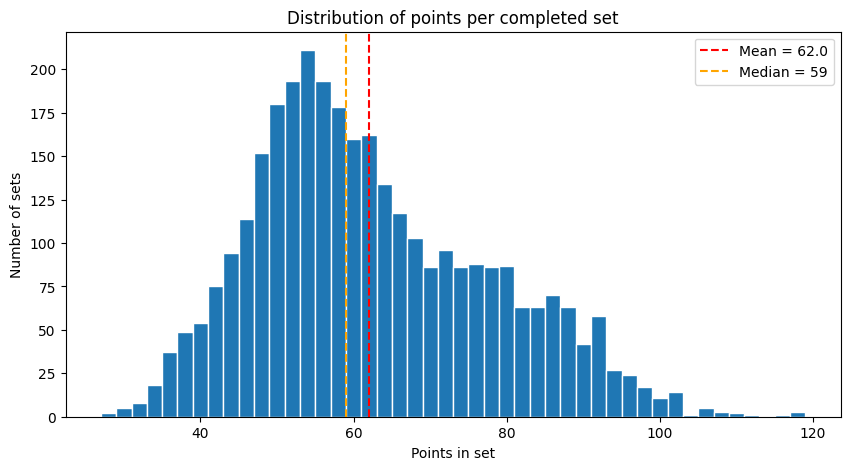

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(sets["total_pts"], bins=range(sets["total_pts"].min(), sets["total_pts"].max() + 2, 2), edgecolor="white")
ax.axvline(sets["total_pts"].mean(), color="red", linestyle="--", label=f"Mean = {sets['total_pts'].mean():.1f}")
ax.axvline(sets["total_pts"].median(), color="orange", linestyle="--", label=f"Median = {sets['total_pts'].median():.0f}")
ax.set_xlabel("Points in set")
ax.set_ylabel("Number of sets")
ax.set_title("Distribution of points per completed set")
ax.legend()
plt.show()

## By set score

,mean,median,count
score_label,,,
6-0,37.7,36.0,75
6-1,43.7,42.0,251
6-2,49.8,49.0,443
6-3,55.7,54.0,766
6-4,61.4,61.0,811
7-5,74.0,73.0,257
7-6,84.4,84.0,633


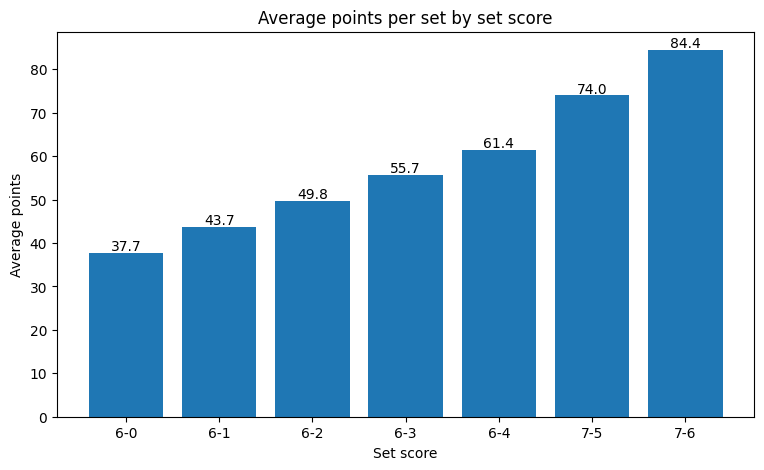

In [4]:
score_order = ["6-0", "6-1", "6-2", "6-3", "6-4", "7-5", "7-6"]
by_score = (
    sets.groupby("score_label")["total_pts"]
    .agg(["mean", "median", "count"])
    .reindex(score_order)
)
display(by_score.round(1))

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(by_score.index, by_score["mean"])
ax.set_xlabel("Set score")
ax.set_ylabel("Average points")
ax.set_title("Average points per set by set score")
for i, v in enumerate(by_score["mean"]):
    ax.text(i, v + 0.5, f"{v:.1f}", ha="center")
plt.show()

## By set number

,mean,median,count
set_number,,,
1,62.1,59.0,1386
2,61.9,59.0,1367
3,62.2,60.0,483


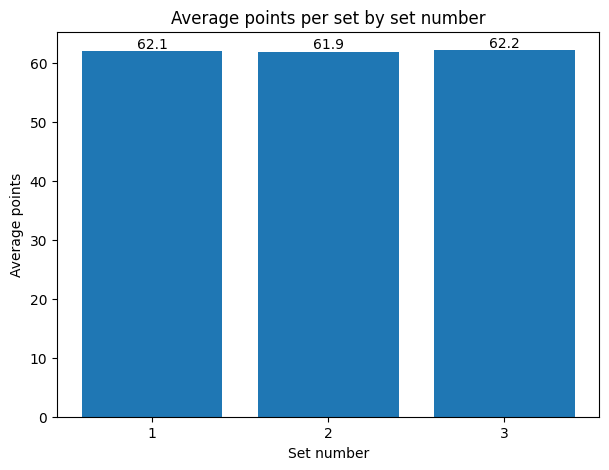

In [5]:
by_set_num = sets.groupby("set_number")["total_pts"].agg(["mean", "median", "count"])
display(by_set_num.round(1))

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(by_set_num.index.astype(str), by_set_num["mean"])
ax.set_xlabel("Set number")
ax.set_ylabel("Average points")
ax.set_title("Average points per set by set number")
for i, v in enumerate(by_set_num["mean"]):
    ax.text(i, v + 0.5, f"{v:.1f}", ha="center")
plt.show()

## By surface

In [6]:
by_surface = sets.groupby("surface")["total_pts"].agg(["mean", "median", "count"])
by_surface.round(1)

,mean,median,count
surface,,,
Clay,61.9,59.0,1661
Hard,62.2,59.0,1575
